# The method, worked through on one fleuron

The candidate-extraction benchmark measured recall of 0.746 at IoU 0.50 and identified the
reason it cannot be improved by tuning: where fleuron ink touches neighbouring ink,
connected-component labelling merges the two into a single region and the fleuron never
receives its own bounding box. That is a property of the method family, not of its parameters.

Retrieval cannot address it. It ranks crops that already exist, so an impression that was never
cut out of the scan is invisible to it. A detector does not threshold pixels: it learns
appearance, and connected ink is no obstacle to recognising a shape.

This notebook builds the method on a single fleuron, `Fleuron_2`, and reports what it found.
It is the worked example; the rest of the chapter is elsewhere, so that no result is stated
twice and left to drift:

| Notebook | Question |
|---|---|
| **1, this one** | How is a single-target detector built, and what does it find? |
| `2_FourTargets` | What did four detectors recover across the corpus, and what did review confirm? |
| `3_Validation` | How well does it work on a book it has never seen? |
| `4_Baselines` | Was training necessary, against a method that needs none? |

---

**Reads** the frozen post-retrieval, pre-detection catalogue as training boxes · **Writes**
`4_detection_outputs/`, trained detector, detections, review sheets · **Chapter README** §2-§4

## 1. Why a single-fleuron detector

A general fleuron detector is not trainable from this catalogue. Over the 514 scans that
carry at least one catalogued crop, the catalogue covers a median of 39% of the candidate
boxes on a scan, and rendering its labels back onto scans confirms that many genuine
fleurons carry none. A detector trained on such scans is taught that most fleurons are
background, and only 28 scans reach 90% label coverage, too few to train on. Both figures
are measured against the pre-detection snapshot configured below, which is the catalogue
this detector was trained from.

Restricting the target to one fleuron removes the problem rather than mitigating it. Every
*other* fleuron on a training scan is then a correct negative rather than a missing label:
for the target used here, the scans carrying it hold 845 other catalogued fleurons, all of
which the model should reject. The only remaining gap is uncatalogued impressions of the
target itself, which is precisely the quantity the experiment sets out to measure.

## 2. Configuration

In [1]:
import json, os, shutil, sys
from pathlib import Path

import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '4_detection', 'Run this notebook from its own folder, 4_detection/.'
PROJECT_DIR = NOTEBOOK_DIR.parent
CORPUS_DIR  = PROJECT_DIR.parent

# Bibliographic identity comes from the corpus-wide rule, never from a filename prefix:
# sibling volumes of one work share ornament stock, and treating them as different books
# is the defect audited in 3_Validation §1.
sys.path.insert(0, str(PROJECT_DIR))
from book_identifiers import build_work_map, volume_id

TARGET     = 'Fleuron_2'
IMAGE_DIRS = {'original': CORPUS_DIR/'Images', 'suppl': CORPUS_DIR/'images suppl'}

# The current, live manifest, not feature_extraction_outputs/.../features_manifest.csv,
# which is a 2026-07-31 snapshot that predates every catalogue change made since (retrieval
# fold-ins, the Fleuron_38/17 split, this chapter's own fold-in of confirmed detections).
MANIFEST_PATH = PROJECT_DIR/'all_regions_outputs'/'features'/'features_manifest.csv'
# Frozen after retrieval and before any detection recovery was folded into the catalogue.
# Using the live final catalogue here would leak this chapter's own answers into training.
CATALOGUE_DIR = (PROJECT_DIR.parent/'curation_backups'/
                 '2026-08-04_1644_pre_detection_foldin'/
                 'Fleurons_v2_plus_retrieval')

OUTPUT_DIR = PROJECT_DIR/'4_detection_outputs'/f'{TARGET.lower()}_v1'
REVIEW_DIR = OUTPUT_DIR/'review_new_detections'
RUNS_DIR   = PROJECT_DIR/'4_detection_outputs'/'runs'

IOU_MATCH   = 0.40   # a detection is credited to a candidate box above this overlap
CONF_MIN    = 0.25   # detection confidence floor
RANDOM_SEED = 42

# Long-running or destructive stages are opt-in, so the notebook can be re-executed
# end to end without retraining or overwriting a review in progress.
RUN_TRAINING = False
RUN_EXPORT   = False

print('target   :', TARGET)
print('outputs  :', OUTPUT_DIR.relative_to(PROJECT_DIR))

target   : Fleuron_2
outputs  : 4_detection_outputs/fleuron_2_v1


## 3. Training data

Positive scans are those containing at least one verified impression of the target; only
the target is boxed. An equal number of negative scans is drawn from scans that hold
catalogued fleurons but no instance of the target, so the model must discriminate between
fleurons rather than simply locate fleuron-like shapes.

The split below is the one this run used, and **it is not the protocol the chapter reports**.
It groups scans by a prefix taken from the filename, which treats sibling volumes of one work
as different books, and it holds out a single validation set rather than cross-validating.
`3_Validation` audits it, withdraws every figure measured on it, and replaces it with
leave-one-work-out over `book_identifiers.py` work identities. The split is kept here because
the corpus detections and the review labels that carry this chapter were produced from this
model, and because the defect is part of the record.

The reasoning that motivated a book-level rather than scan-level split still holds:
impressions of one fleuron recur many times within a book, so a scan-level split would place
near-identical images on both sides of it. What was wrong was the definition of a book.

In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
manifest['crop_name'] = manifest.crop_path.map(lambda p: Path(p).name)

catalogue = {}
for folder in CATALOGUE_DIR.iterdir():
    if folder.is_dir():
        for f in folder.iterdir():
            name = (Path(os.readlink(f)) if f.is_symlink() else f).name
            catalogue[name] = folder.name.split(' (')[0]

manifest['klass']  = manifest.crop_name.map(catalogue)
manifest['volume'] = manifest.rel_path.map(volume_id)
_work_of, _       = build_work_map(sorted(manifest.volume.unique()))
manifest['work']  = manifest.volume.map(_work_of)

target_rows = manifest[manifest.klass == TARGET]
target_scans = set(target_rows.stem)
others = manifest[manifest.stem.isin(target_scans) & manifest.klass.notna()
                  & (manifest.klass != TARGET)]

print(f'{TARGET}: {len(target_rows)} impressions on {len(target_scans)} scans, '
      f'{target_rows.volume.nunique()} volumes, {target_rows.work.nunique()} works')
print(f'box size  median {target_rows.width.median():.0f}x{target_rows.height.median():.0f} px'
      f'   range {target_rows.width.min():.0f}-{target_rows.width.max():.0f} px')
print(f'other catalogued ornaments on those scans: {len(others)} (correct negatives)')

Fleuron_2: 265 impressions on 78 scans, 21 volumes, 17 works
box size  median 71x86 px   range 24-114 px
other catalogued ornaments on those scans: 845 (correct negatives)


## 4. Label verification

No metric reveals inconsistent box geometry; only drawing the exported labels back onto the
source scans does. This check is run before training, and it is what established that the
catalogue's boxes are consistent motif units rather than a mixture of whole border bands
and single motifs.

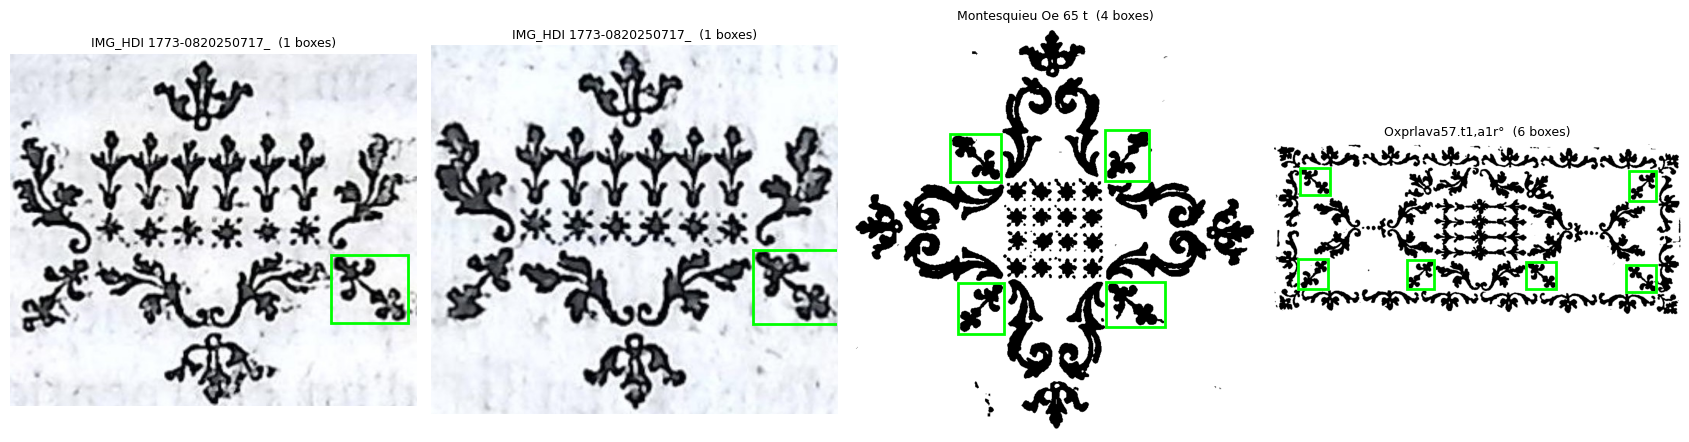

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

sample = sorted(target_scans)[:4]
fig, axes = plt.subplots(1, 4, figsize=(17, 5))
for ax, stem in zip(axes, sample):
    rows = manifest[manifest.stem == stem]
    scan = Image.open(IMAGE_DIRS[rows.source.iloc[0]]/rows.rel_path.iloc[0]).convert('RGB')
    ax.imshow(scan)
    hits = rows[rows.klass == TARGET]
    for r in hits.itertuples():
        ax.add_patch(patches.Rectangle((r.x_min, r.y_min), r.x_max-r.x_min, r.y_max-r.y_min,
                                       fill=False, color='lime', lw=2))
    ax.set_title(f'{stem[:24]}  ({len(hits)} boxes)', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Augmentation: rotation degrades axis-aligned boxes

The target appears at several orientations and at scales from 33 to 129 px, which suggests
rotation augmentation. For an axis-aligned detector this reasoning is wrong, and the error
is worth recording because its effect on the result is large.

Rotating a training image by an arbitrary angle forces the framework to recompute the
axis-aligned box enclosing the rotated object. That box is always larger, and closer to
square, than the original. The model is therefore trained on inflated targets and learns to
reproduce them. Horizontal and vertical flips do not have this property: they map an
axis-aligned box onto an axis-aligned box of identical dimensions, so mirrored impressions
can be learned without any loss of box tightness.

Two runs were trained differing **only** in the `degrees` parameter.

| | `degrees=180` | flips only |
|---|---:|---:|
| Precision | 0.684 | 0.879 |
| Recall | 0.544 | 0.915 |
| mAP50 | 0.633 | 0.935 |
| mAP50-95 | 0.405 | 0.808 |

| box geometry | near-square (AR 0.9-1.1) | AR p10-p90 |
|---|---:|---|
| training boxes | 34% | 0.55-1.15 |
| `degrees=180` | 80% | 0.96-1.13 |
| flips only | 45% | 0.53-1.14 |

The doubling of mAP50-95, which is the localisation-sensitive metric, and the recovery of
the training set's aspect-ratio distribution both follow from the same cause. Flip-only
augmentation is used for all results reported below.

*The two columns are internally comparable, since both runs were trained and scored under
identical conditions and differ in one parameter. Their absolute values are withdrawn: §1 of
`3_Validation` shows the split that produced them did not hold out what it claimed to. Only
the difference between the columns is interpreted.*

In [4]:
from ultralytics import YOLO

def train(name, degrees):
    model = YOLO('yolo11n.pt')
    return model.train(data=str(OUTPUT_DIR/'data.yaml'), epochs=80, imgsz=640, batch=8,
                       degrees=degrees, flipud=0.5, fliplr=0.5, scale=0.5, mosaic=1.0,
                       project=str(RUNS_DIR), name=name, exist_ok=True,
                       patience=25, seed=RANDOM_SEED, verbose=False, plots=True)

if RUN_TRAINING:
    train('fleuron_2_rotation',  degrees=180)   # recorded for the comparison above
    train('fleuron_2_flipsonly', degrees=0)     # selected model
else:
    print('RUN_TRAINING is False - using the stored weights.')

WEIGHTS = RUNS_DIR/'fleuron_2_flipsonly'/'weights'/'best.pt'
print('weights:', WEIGHTS.name, '| present:', WEIGHTS.exists())

RUN_TRAINING is False - using the stored weights.
weights: best.pt | present: True


## 6. Detection over the corpus, and attribution to the candidate set

The selected model is applied to every scan and each detection is matched against the
candidate boxes the segmentation stage produced for that scan, taking whichever overlaps it
most above `IOU_MATCH`.

**Presence of a candidate box is not evidence that the impression was usefully extracted.**
The connectivity failure that merges a fleuron with adjacent ink can equally truncate it,
leaving a fragment; both produce a candidate a curator would reject. Attributing either to
the clustering stage would credit a segmentation failure to the wrong place. Detections are
therefore sub-classified by the ratio of candidate-box area to detection area:

- **`known_target`**: overlaps a catalogued impression of the target;
- **`no_otsu_candidate`**: no candidate box at this location. This bucket conflates two
  failures and the chapter README §4.2 separates them: matching is made against the candidate
  set that was embedded, which is what survived a `MIN_SIDE` >= 24 filter applied after
  extraction, so a detection landing on one of the 9,054 discarded regions records no candidate
  even though Otsu produced one. Of the 436 confirmed recoveries in this bucket, 365 had no
  region at any size and 71 had one below the filter;
- **`otsu_box_fragment`**: a candidate exists but is under `FRAGMENT_RATIO` of the
  detection, so the stage captured only part of the fleuron;
- **`otsu_box_merged`**: a candidate exists but exceeds `MERGE_RATIO`, so the fleuron was
  absorbed into a larger region;
- **`otsu_box_ok_uncurated`**: a candidate of comparable size that was not carried into
  the catalogue;
- **`other_catalogued`**: the detection lands on a different catalogued fleuron.

Matching is assigned through the detection frame's own index. Grouping the detections and
appending results in group order would silently misalign the labels against the original
row order.


In [5]:
def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/union if union > 0 else 0.0


def detect_corpus(weights):
    model = YOLO(str(weights))
    scans = manifest[['rel_path', 'source', 'stem']].drop_duplicates()
    rows = []
    for p in scans.itertuples():
        path = IMAGE_DIRS[p.source]/p.rel_path
        if not path.exists():
            continue
        res = model.predict(str(path), conf=CONF_MIN, verbose=False, device=0)[0]
        for box, conf in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
            rows.append(dict(stem=p.stem, rel_path=p.rel_path, source=p.source,
                             x1=box[0], y1=box[1], x2=box[2], y2=box[3], conf=float(conf)))
    return pd.DataFrame(rows)


FRAGMENT_RATIO = 0.67   # candidate box this much smaller than the detection: a fragment
MERGE_RATIO    = 1.50   # candidate box this much larger: absorbed into a bigger region


def attribute(det):
    by_scan = {s: g for s, g in manifest.groupby('stem')}
    bucket  = pd.Series(index=det.index, dtype=object)
    matched = pd.Series(index=det.index, dtype=object)
    ratio   = pd.Series(index=det.index, dtype=float)
    for i, r in det.iterrows():
        cand = by_scan.get(r.stem)
        if cand is None or not len(cand):
            bucket[i] = 'no_otsu_candidate'; continue
        boxes = cand[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()
        klass = cand.klass.to_numpy()
        overlaps = np.array([iou([r.x1, r.y1, r.x2, r.y2], b) for b in boxes])
        if overlaps.max() < IOU_MATCH:
            bucket[i] = 'no_otsu_candidate'; continue
        j = overlaps.argmax(); k = klass[j]; matched[i] = k
        box = boxes[j]
        det_area = (r.x2-r.x1) * (r.y2-r.y1)
        ratio[i] = ((box[2]-box[0]) * (box[3]-box[1]) / det_area) if det_area > 0 else np.nan
        if k == TARGET:            bucket[i] = 'known_target'
        elif pd.notna(k):          bucket[i] = 'other_catalogued'
        elif ratio[i] < FRAGMENT_RATIO: bucket[i] = 'otsu_box_fragment'
        elif ratio[i] > MERGE_RATIO:    bucket[i] = 'otsu_box_merged'
        else:                      bucket[i] = 'otsu_box_ok_uncurated'
    return det.assign(bucket=bucket, matched_class=matched, otsu_area_ratio=ratio)


DETECTIONS_PATH = OUTPUT_DIR/'detections_flipsonly.csv'
if RUN_TRAINING or not DETECTIONS_PATH.exists():
    detections = attribute(detect_corpus(WEIGHTS))
    detections.to_csv(DETECTIONS_PATH, index=False)
else:
    detections = pd.read_csv(DETECTIONS_PATH)

print(f'{len(detections)} detections on {detections.stem.nunique()} scans\n')
print(detections.bucket.value_counts().to_string())

360 detections on 110 scans

bucket
known_target             254
no_otsu_candidate         35
otsu_box_ok_uncurated     33
other_catalogued          15
otsu_box_fragment         15
otsu_box_merged            8


## 7. Error analysis

Detections falling on a different catalogued fleuron are the only errors that can be
identified without further human review. They give a lower bound on the error count (and
therefore an upper bound on precision before the remaining proposals are reviewed).

In [6]:
known = int((detections.bucket == 'known_target').sum())
conf  = int((detections.bucket == 'other_catalogued').sum())
print(f'precision on automatically checkable detections: {known}/{known+conf} = '
      f'{known/(known+conf):.3f}\n')
print('ornaments confused with the target:')
print(detections[detections.bucket == 'other_catalogued']
      .matched_class.value_counts().to_string())

precision on automatically checkable detections: 254/269 = 0.944

ornaments confused with the target:
matched_class
Fleuron_20    6
Fleuron_45    4
Fleuron_30    2
Fleuron_10    2
Fleuron_55    1


The confusions are concentrated on small florets of similar outline. The same limitation
was recorded independently while auditing the catalogue with cosine similarity, where the
descriptor was found unable to resolve lobe count on small florets. Two methods that share
no components failing on the same material indicates a property of the material rather than
of either method.

Removing rotation augmentation reduced confusions from 70 to 15 and changed which fleurons
were involved: the largest single error of the first run disappeared entirely. Inflated
boxes were overlapping neighbouring fleurons, so part of what appeared to be visual
confusion was a localisation failure.

## 8. Candidate recoveries and the review

Detections in the `no_otsu_candidate` and `otsu_candidate_rejected` buckets are candidate
recoveries. They are exported as image crops, split by bucket and named by confidence so
the strongest sort first, and reviewed by deleting those that are not the target.

The export is guarded: it will not overwrite a review directory that already exists, since
doing so would discard the decisions recorded in it.

In [7]:
new = detections[detections.bucket.isin(['no_otsu_candidate', 'otsu_box_fragment',
                                     'otsu_box_merged', 'otsu_box_ok_uncurated'])] \
        .sort_values('conf', ascending=False)
print(f'{len(new)} candidate recoveries')
print(new.bucket.value_counts().to_string())

if RUN_EXPORT and not REVIEW_DIR.exists():
    for b in ['A_no_otsu_candidate', 'B_otsu_rejected_by_clustering']:
        (REVIEW_DIR/b).mkdir(parents=True)
    for i, r in enumerate(new.itertuples()):
        sub = ('A_no_otsu_candidate' if r.bucket == 'no_otsu_candidate'
               else 'B_otsu_rejected_by_clustering')
        scan = Image.open(IMAGE_DIRS[r.source]/r.rel_path).convert('L')
        scan.crop((max(0, r.x1-6), max(0, r.y1-6),
                   min(scan.size[0], r.x2+6), min(scan.size[1], r.y2+6))) \
            .save(REVIEW_DIR/sub/f'{round(r.conf*1000):04d}_{Path(r.rel_path).stem[:24]}_{i:03d}.png')
    new.to_csv(REVIEW_DIR/'new_detections.csv', index=False)
    print('exported for review')
elif REVIEW_DIR.exists():
    print(f'review directory already present at {REVIEW_DIR.name} - export skipped')

91 candidate recoveries
bucket
no_otsu_candidate        35
otsu_box_ok_uncurated    33
otsu_box_fragment        15
otsu_box_merged           8
review directory already present at review_new_detections - export skipped


## 9. Confirmed recoveries for this target

Run after review. Surviving crops are read back from the review directories and the confirmed
count is reported per bucket and per confidence band. Until this has been run against a
completed review, no recovery count is established.

The figures below are for `Fleuron_2` alone. **The pooled result across all four targets, and
the correction separating the two kinds of extraction failure, are in `2_FourTargets`**, which
recomputes everything from the frozen review tables.

In [8]:
if REVIEW_DIR.exists() and (REVIEW_DIR/'new_detections.csv').exists():
    survivors = set()
    for folder in REVIEW_DIR.iterdir():
        if folder.is_dir():
            survivors |= {f.name.split('_')[-1].replace('.png', '') for f in folder.iterdir()}
    exported = pd.read_csv(REVIEW_DIR/'new_detections.csv').reset_index(drop=True)
    exported['confirmed'] = [f'{i:03d}' in survivors for i in range(len(exported))]

    print('confirmed recoveries by bucket:')
    print(exported.groupby('bucket').confirmed.agg(proposed='size', confirmed='sum').to_string())
    print()
    exported['band'] = pd.cut(exported.conf, [0.25, 0.5, 0.75, 0.9, 1.0])
    print(exported.groupby('band', observed=True)
          .agg(proposed=('confirmed', 'size'), confirmed=('confirmed', 'sum')).to_string())
else:
    print('No review present yet.')

confirmed recoveries by bucket:
                       proposed  confirmed
bucket                                    
no_otsu_candidate            35         26
otsu_box_fragment            15         13
otsu_box_merged               8          5
otsu_box_ok_uncurated        33         10

             proposed  confirmed
band                            
(0.25, 0.5]        46         20
(0.5, 0.75]        32         22
(0.75, 0.9]        12         11
(0.9, 1.0]          1          1


## 10. The other three targets

`Fleuron_74`, `Fleuron_73` and `Fleuron_72` were run through the identical procedure using the
parametrised script `_tools/train_single_fleuron_detector.py` rather than by re-executing this
notebook per target. Each was chosen in response to what the previous one measured, and they are
reported as case studies rather than as a sample.

**Their results are in `2_FourTargets`**, which reads the same frozen artifacts this notebook
writes. They are not repeated here.

One finding from that sequence belongs to the method rather than to any one target, and is the
subject of the next section: `Fleuron_74` located its design almost perfectly and misnamed it
103 times.

## 11. Detection and retrieval are complementary

The `Fleuron_74` failure is one of identification, not of localisation: the detector found the
fleurons and misnamed them. Identification is what the retrieval stage does, and it operates on
the extracted crop, where interior detail is preserved.

This suggests a two-stage arrangement, the detector proposes locations, and similarity against
the catalogue assigns identity, which is testable directly on the 103 confusions.

Each confused detection is cropped from its scan, binarised and embedded exactly as the
catalogue was, and assigned to the class of its most similar catalogue member. **The overlapped
catalogue crop is excluded from the reference set**, since the detection covers nearly the same
region and would otherwise be matched against itself.

In [9]:
# Requires the DINOv2 model; ~2 minutes on GPU. Set to True to re-run.
RUN_TWO_STAGE = False

TWO_STAGE_PATH = PROJECT_DIR/'4_detection_outputs'/'fleuron_74_v1'/'two_stage_check.csv'
if TWO_STAGE_PATH.exists():
    ts = pd.read_csv(TWO_STAGE_PATH)
    correct = int((ts.retrieval_said == ts.truth).sum())
    print(f'detector confusions re-identified by retrieval: {correct}/{len(ts)} '
          f'= {correct/len(ts):.3f}   (stored table)')
    print(f'still misassigned to the detector target: '
          f'{int((ts.retrieval_said == "Fleuron_74").sum())}')
    print()
    print('by true class:')
    print(ts.assign(ok=ts.retrieval_said == ts.truth)
            .groupby('truth').ok.agg(cases='size', correct='sum').to_string())
else:
    print('Two-stage check not present; set RUN_TWO_STAGE = True.')

detector confusions re-identified by retrieval: 103/103 = 1.000   (stored table)
still misassigned to the detector target: 0

by true class:
            cases  correct
truth                     
Fleuron_11     18       18
Fleuron_19      2        2
Fleuron_46      2        2
Fleuron_6      15       15
Fleuron_7       4        4
Fleuron_73     62       62


The stored table records every confusion as resolved, including all 62 `Fleuron_73` cases,
with none left assigned to the detector's target. The generating code and neighbour
identifiers were not preserved, so its stated leave-one-out exclusion cannot be independently
audited from this artifact.

The two stages therefore fail in complementary ways and correct one another:

| | can locate an unextracted impression | can distinguish similar designs |
|---|---|---|
| Retrieval alone | no, it ranks crops that already exist | yes |
| Detection alone | yes | no, at scan scale it sees only outline |
| Detection then retrieval | yes | yes |

This is encouraging exploratory evidence for the pipeline architecture on the 103
`Fleuron_74` confusion locations, not a reproducible validation. It has not
yet tested retrieval-based identity assignment on the 365 recoveries for which extraction made
no region, so the full detection→retrieval claim remains a required analysis rather than a
completed validation. The result also converges with two
earlier observations made by unrelated means: that the descriptor cannot resolve lobe count
on small florets, and that the clustering audit's residual errors involve visually similar
designs. The material contains groups of fleurons that share outline and differ only in
detail, and every method examined here is limited by it at the resolution at which it works.

## 12. What this notebook establishes, and what it does not

The detector reproduces the catalogued impressions of its target and proposes further locations,
some of which the extraction stage never produced a region for. Where those are confirmed, they
are impressions recoverable only by a method that does not depend on ink connectivity, and they
were obtained without any manual annotation beyond the catalogue the earlier stages had already
produced.

Four limits apply, and each is measured elsewhere in the chapter rather than asserted here.

**The result covers four fleurons**, chosen sequentially as case studies. Generalisation to the
remaining 88 classes is untested and is not claimed (`2_FourTargets`).

**The detector can only learn designs the extraction stage surfaced at least sometimes**, so it
extends coverage of known fleurons and cannot discover designs absent from the catalogue.

**The validation figures this notebook's protocol produces are not evidence of generalisation.**
The splits held out volumes rather than works, and one target trained on its own validation set.
`3_Validation` withdraws them and replaces them with cross-validation over 208 trained models,
which also shows that run-to-run variation reaches 0.2 in recall, bounding every comparison the
chapter makes.

**Training may not have been necessary.** `4_Baselines` runs a training-free matcher under
matched conditions and finds it competitive on three of the four targets.